In [1]:
# import torch
# import torch.nn.functional as F
# import sys
# sys.path.append("..")
# from model import longclip
# from types import SimpleNamespace
# from train import CLIP_Clean_Train
# from docci import DocciDataset
# from dci import JsonDCIDataset
# from torch.utils.data import DataLoader

# def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
#     args = SimpleNamespace(
#         base_model='ViT-B/16',
#         download_root=None,
#         log_scale=4.6052,
#         batch_size=64,
#         epochs=1,
#         lr=1e-5,
#         refine_lr_image=2e-6,
#         refine_lr_text=2e-4,
#         weight_decay=0.01,
#         warmup_length=200,
#         exp_name='inference',
#         ckpt_path=ckpt_path
#     )
#     trainer = CLIP_Clean_Train(args)
#     state = torch.load(ckpt_path, map_location='cpu')
#     trainer.model.load_state_dict(state, strict=False)
#     model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
#     model = model.to(device).eval()
#     return trainer, model

# @torch.no_grad()
# def encode_and_compare(long_texts, trainer, model, device):
#     results = []
#     for text in long_texts:
#         # encode long text
#         tokens_long = longclip.tokenize([text], truncate=True).to(device)
#         feat_long   = model.encode_text(tokens_long)
#         feat_long   = feat_long / feat_long.norm(dim=-1, keepdim=True)

#         # split into detail captions
#         details = trainer.split_into_detail_captions(text)

#         sims = []
#         for detail in details:
#             if not detail.strip():
#                 sims.append(0.0)
#                 continue
#             tokens_det = longclip.tokenize([detail], truncate=True).to(device)
#             feat_det   = model.encode_text(tokens_det)
#             feat_det   = feat_det / feat_det.norm(dim=-1, keepdim=True)
#             sims.append((feat_long @ feat_det.T).item())

#         results.append({
#             'long_text': text,
#             'details':   details,
#             'sims':      sims,
#         })
#     return results

# if __name__ == '__main__':
#     device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--06_31_44_-dci-learnable-test_spm.pt"

#     # 1) Load model
#     trainer, model = load_trainer_and_model(ckpt_path, device)

#     # 2) Prepare test dataloader
#     test_ds  = JsonDCIDataset(
#         json_path="/home/ubuntu/hieu.tq/Git/GOAL/datasets/DCI_test.json",
#         max_items=None
#     )
#     test_loader = DataLoader(
#         test_ds,
#         batch_size=8,     # select batch size bạn muốn
#         shuffle=False,
#         num_workers=4,
#         pin_memory=True
#     )

#     # 3) Lấy 1 batch đầu tiên từ test_loader để demo
#     for batch in test_loader:
#         # batch format: (image_tensors, long_texts, ..., image_paths, ...)
#         _, long_texts, *rest = batch
#         break

#     # 4) Encode và so sánh
#     results = encode_and_compare(long_texts, trainer, model, device)

#     # 5) In ra kết quả cho mỗi sample trong batch
#     for r in results:
#         print("Long text:", r['long_text'])
#         for detail, sim in zip(r['details'], r['sims']):
#             print(f"  Detail: {detail!r:50} → cos_sim = {sim:.4f}")
#         print("-" * 80)


In [2]:
# import torch
# import torch.nn.functional as F
# import sys
# sys.path.append("..")
# from model import longclip
# from types import SimpleNamespace
# from train import CLIP_Clean_Train
# from dci import JsonDCIDataset
# from torch.utils.data import DataLoader

# def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
#     args = SimpleNamespace(
#         base_model='ViT-B/16',
#         download_root=None,
#         log_scale=4.6052,
#         batch_size=64,
#         epochs=1,
#         lr=1e-5,
#         refine_lr_image=2e-6,
#         refine_lr_text=2e-4,
#         weight_decay=0.01,
#         warmup_length=200,
#         exp_name='inference',
#         ckpt_path=ckpt_path
#     )
#     trainer = CLIP_Clean_Train(args)
#     state   = torch.load(ckpt_path, map_location='cpu')
#     trainer.model.load_state_dict(state, strict=False)
#     model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
#     return model.to(device).eval(), trainer

# @torch.no_grad()
# def encode_and_compare_batch(batch, trainer, model, device, nums_details=12):
#     """
#     Với 1 batch:
#       - encode long_texts → feats_long [B, D]
#       - split chi tiết → K = nums_details (pad nếu thiếu)
#       - encode mỗi detail j → feats_det [B, K, D]
#       - detail_dots = feats_det ⋅ feats_long  → [B, K]
#       - detail_weights = softmax(detail_dots, dim=1)
#     Trả về list kết quả cho từng sample.
#     """
#     _, long_texts, *rest = batch
#     B = len(long_texts)

#     # 1) Encode full (long) texts
#     tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
#     feats_long  = model.encode_text(tokens_long)
#     feats_long  = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]

#     # 2) Split into detail captions và pad đến nums_details
#     raw_details = [trainer.split_into_detail_captions(t) for t in long_texts]
#     padded = [d + [""]*(nums_details - len(d)) if len(d) < nums_details else d[:nums_details]
#               for d in raw_details]  # list of lists, [B x nums_details]

#     # 3) Encode each detail position j across the batch
#     feats_det_list = []
#     for j in range(nums_details):
#         texts_j = [padded[i][j] for i in range(B)]
#         toks_j   = longclip.tokenize(texts_j, truncate=True).to(device)
#         f_j      = model.encode_text(toks_j)
#         f_j      = f_j / f_j.norm(dim=-1, keepdim=True)  # [B, D]
#         feats_det_list.append(f_j)
#     # stack → [B, K, D]
#     feats_det = torch.stack(feats_det_list, dim=1)

#     # 4) Compute raw dot-products and softmax weights
#     detail_dots    = torch.einsum('bkd,bd->bk', feats_det, feats_long)    # [B, K]
#     detail_weights = torch.softmax(detail_dots, dim=1)                    # [B, K]

#     # 5) Format results
#     results = []
#     for i in range(B):
#         results.append({
#             'long_text':   long_texts[i],
#             'details':     padded[i],
#             'dots':        detail_dots[i].tolist(),
#             'weights':     detail_weights[i].tolist(),
#         })
#     return results

# if __name__ == '__main__':
#     device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--06_31_44_-dci-learnable-test_spm.pt"

#     # 1) Load model + trainer
#     model, trainer = load_trainer_and_model(ckpt_path, device)

#     # 2) Prepare test dataloader
#     test_ds      = JsonDCIDataset(
#         json_path="/home/ubuntu/hieu.tq/Git/GOAL/datasets/DCI_test.json",
#         max_items=None
#     )
#     test_loader  = DataLoader(
#         test_ds,
#         batch_size=8,
#         shuffle=False,
#         num_workers=4,
#         pin_memory=True
#     )

#     # 3) Lấy batch đầu tiên rồi compute
#     for batch in test_loader:
#         results = encode_and_compare_batch(batch, trainer, model, device, nums_details=12)
#         break

#     # 4) In kết quả
#     for r in results:
#         print("Long text:", r['long_text'])
#         for det, dot, w in zip(r['details'], r['dots'], r['weights']):
#             print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
#         print("-" * 80)


In [8]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_batch(batch, trainer, model, device, nums_details=12):
    """
    Với 1 batch:
      - encode long_texts → feats_long [B, D]
      - split chi tiết → K = nums_details (pad nếu thiếu)
      - encode mỗi detail j → feats_det [B, K, D]
      - detail_dots = feats_det ⋅ feats_long  → [B, K]
      - detail_weights = softmax(detail_dots, dim=1)
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)

    # 1) Encode full (long) texts
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long  = model.encode_text(tokens_long)
    feats_long  = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]

    # 2) Split into detail captions và pad đến nums_details
    raw_details = [trainer.split_into_detail_captions(t) for t in long_texts]
    padded = [d + [""]*(nums_details - len(d)) if len(d) < nums_details else d[:nums_details]
              for d in raw_details]  # list of lists, [B x nums_details]

    # 3) Encode each detail position j across the batch
    feats_det_list = []
    for j in range(nums_details):
        texts_j = [padded[i][j] for i in range(B)]
        toks_j   = longclip.tokenize(texts_j, truncate=True).to(device)
        f_j      = model.encode_text(toks_j)
        f_j      = f_j / f_j.norm(dim=-1, keepdim=True)  # [B, D]
        feats_det_list.append(f_j)
    # stack → [B, K, D]
    feats_det = torch.stack(feats_det_list, dim=1)

    # 4) Compute raw dot-products and softmax weights
    detail_dots    = torch.einsum('bkd,bd->bk', feats_det, feats_long)    # [B, K]
    detail_weights = torch.softmax(detail_dots, dim=1)                    # [B, K]

    # 5) Format results
    results = []
    for i in range(B):
        results.append({
            'long_text':   long_texts[i],
            'details':     padded[i],
            'dots':        detail_dots[i].tolist(),
            'weights':     detail_weights[i].tolist(),
        })
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--17_41_59_-docci-id1.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        results = encode_and_compare_batch(batch, trainer, model, device, nums_details=12)
        break

    # 4) In kết quả
    for r in results:
        print("Long text:", r['long_text'])
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)


Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6993, weight = 0.1416
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.4978, weight = 0.1158
  Detail: 'It is facing the front, right at an angle'        → sim = -0.0677, weight = 0.0658
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right 

In [9]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_batch(batch, trainer, model, device, nums_details=12):
    """
    Với 1 batch:
      - encode long_texts → feats_long [B, D]
      - split chi tiết → K = nums_details (pad nếu thiếu)
      - encode mỗi detail j → feats_det [B, K, D]
      - detail_dots = feats_det ⋅ feats_long  → [B, K]
      - detail_weights = softmax(detail_dots, dim=1)
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)

    # 1) Encode full (long) texts
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long  = model.encode_text(tokens_long)
    feats_long  = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]

    # 2) Split into detail captions và pad đến nums_details
    raw_details = [trainer.split_into_detail_captions(t) for t in long_texts]
    padded = [d + [""]*(nums_details - len(d)) if len(d) < nums_details else d[:nums_details]
              for d in raw_details]  # list of lists, [B x nums_details]

    # 3) Encode each detail position j across the batch
    feats_det_list = []
    for j in range(nums_details):
        texts_j = [padded[i][j] for i in range(B)]
        toks_j   = longclip.tokenize(texts_j, truncate=True).to(device)
        f_j      = model.encode_text(toks_j)
        f_j      = f_j / f_j.norm(dim=-1, keepdim=True)  # [B, D]
        feats_det_list.append(f_j)
    # stack → [B, K, D]
    feats_det = torch.stack(feats_det_list, dim=1)

    # 4) Compute raw dot-products and softmax weights
    detail_dots    = torch.einsum('bkd,bd->bk', feats_det, feats_long)    # [B, K]
    detail_weights = torch.softmax(detail_dots, dim=1)                    # [B, K]

    # 5) Format results
    results = []
    for i in range(B):
        results.append({
            'long_text':   long_texts[i],
            'details':     padded[i],
            'dots':        detail_dots[i].tolist(),
            'weights':     detail_weights[i].tolist(),
        })
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_42_50_-docci-learnable.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        results = encode_and_compare_batch(batch, trainer, model, device, nums_details=12)
        break

    # 4) In kết quả
    for r in results:
        print("Long text:", r['long_text'])
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)


Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6759, weight = 0.1415
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.5269, weight = 0.1220
  Detail: 'It is facing the front, right at an angle'        → sim = -0.1228, weight = 0.0637
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right 

In [10]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_batch(batch, trainer, model, device, nums_details=12):
    """
    Với 1 batch:
      - encode long_texts → feats_long [B, D]
      - split chi tiết → K = nums_details (pad nếu thiếu)
      - encode mỗi detail j → feats_det [B, K, D]
      - detail_dots = feats_det ⋅ feats_long  → [B, K]
      - detail_weights = softmax(detail_dots, dim=1)
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)

    # 1) Encode full (long) texts
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long  = model.encode_text(tokens_long)
    feats_long  = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]

    # 2) Split into detail captions và pad đến nums_details
    raw_details = [trainer.split_into_detail_captions(t) for t in long_texts]
    padded = [d + [""]*(nums_details - len(d)) if len(d) < nums_details else d[:nums_details]
              for d in raw_details]  # list of lists, [B x nums_details]

    # 3) Encode each detail position j across the batch
    feats_det_list = []
    for j in range(nums_details):
        texts_j = [padded[i][j] for i in range(B)]
        toks_j   = longclip.tokenize(texts_j, truncate=True).to(device)
        f_j      = model.encode_text(toks_j)
        f_j      = f_j / f_j.norm(dim=-1, keepdim=True)  # [B, D]
        feats_det_list.append(f_j)
    # stack → [B, K, D]
    feats_det = torch.stack(feats_det_list, dim=1)

    # 4) Compute raw dot-products and softmax weights
    detail_dots    = torch.einsum('bkd,bd->bk', feats_det, feats_long)    # [B, K]
    detail_weights = torch.softmax(detail_dots, dim=1)                    # [B, K]

    # 5) Format results
    results = []
    for i in range(B):
        results.append({
            'long_text':   long_texts[i],
            'details':     padded[i],
            'dots':        detail_dots[i].tolist(),
            'weights':     detail_weights[i].tolist(),
        })
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        results = encode_and_compare_batch(batch, trainer, model, device, nums_details=12)
        break

    # 4) In kết quả
    for r in results:
        print("Long text:", r['long_text'])
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)


Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6904, weight = 0.1394
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.5400, weight = 0.1199
  Detail: 'It is facing the front, right at an angle'        → sim = -0.0721, weight = 0.0650
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right 

# New version

In [3]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt với số lượng detail động:
      - Lặp qua từng sample trong batch
      - Với mỗi sample: encode long_text và tất cả details của nó
      - Tính similarity và weights cho từng sample riêng
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        
        # 1) Encode long text của sample này
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)  # [1, D]
        feat_long = feat_long.squeeze(0)  # [D]
        
        # 2) Split thành detail captions
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        
        if num_details == 0:
            # Trường hợp không có detail nào
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # 3) Encode tất cả details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)  # [num_details, D]
        
        # 4) Tính dot products và weights
        detail_dots = torch.matmul(feats_details, feat_long)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)    # [num_details]
        
        # 5) Lưu kết quả
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
    
    return results

@torch.no_grad()
def encode_and_compare_batch_optimized(batch, trainer, model, device):
    """
    Phiên bản tối ưu hơn: group các detail theo độ dài để batch processing hiệu quả hơn
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    # 1) Encode tất cả long texts cùng lúc
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long = model.encode_text(tokens_long)
    feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]
    
    # 2) Tách details cho từng sample
    all_details_info = []
    for i, long_text in enumerate(long_texts):
        details = trainer.split_into_detail_captions(long_text)
        all_details_info.append({
            'sample_idx': i,
            'details': details,
            'long_text': long_text
        })
    
    # 3) Collect tất cả details để encode batch
    all_details_flat = []
    detail_to_sample_map = []
    
    for info in all_details_info:
        for detail in info['details']:
            all_details_flat.append(detail)
            detail_to_sample_map.append(info['sample_idx'])
    
    # 4) Encode tất cả details cùng lúc (nếu có)
    if len(all_details_flat) > 0:
        tokens_details = longclip.tokenize(all_details_flat, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
    
    # 5) Tính toán kết quả cho từng sample
    results = []
    detail_idx = 0
    
    for info in all_details_info:
        sample_idx = info['sample_idx']
        details = info['details']
        long_text = info['long_text']
        num_details = len(details)
        
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # Lấy features của details thuộc sample này
        sample_detail_feats = feats_details[detail_idx:detail_idx + num_details]  # [num_details, D]
        sample_long_feat = feats_long[sample_idx]  # [D]
        
        # Tính similarity và weights
        detail_dots = torch.matmul(sample_detail_feats, sample_long_feat)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)  # [num_details]
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
        
        detail_idx += num_details
    
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        # Sử dụng phiên bản đơn giản
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        
        # Hoặc sử dụng phiên bản tối ưu
        # results = encode_and_compare_batch_optimized(batch, trainer, model, device)
        break

    # 4) In kết quả
    for r in results:
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)

Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6904, weight = 0.2010
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.5400, weight = 0.1729
  Detail: 'It is facing the front, right at an angle'        → sim = -0.0721, weight = 0.0938
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible 

In [2]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt với số lượng detail động:
      - Lặp qua từng sample trong batch
      - Với mỗi sample: encode long_text và tất cả details của nó
      - Tính similarity và weights cho từng sample riêng
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        
        # 1) Encode long text của sample này
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)  # [1, D]
        feat_long = feat_long.squeeze(0)  # [D]
        
        # 2) Split thành detail captions
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        
        if num_details == 0:
            # Trường hợp không có detail nào
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # 3) Encode tất cả details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)  # [num_details, D]
        
        # 4) Tính dot products và weights
        detail_dots = torch.matmul(feats_details, feat_long)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)    # [num_details]
        
        # 5) Lưu kết quả
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
    
    return results

@torch.no_grad()
def encode_and_compare_batch_optimized(batch, trainer, model, device):
    """
    Phiên bản tối ưu hơn: group các detail theo độ dài để batch processing hiệu quả hơn
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    # 1) Encode tất cả long texts cùng lúc
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long = model.encode_text(tokens_long)
    feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]
    
    # 2) Tách details cho từng sample
    all_details_info = []
    for i, long_text in enumerate(long_texts):
        details = trainer.split_into_detail_captions(long_text)
        all_details_info.append({
            'sample_idx': i,
            'details': details,
            'long_text': long_text
        })
    
    # 3) Collect tất cả details để encode batch
    all_details_flat = []
    detail_to_sample_map = []
    
    for info in all_details_info:
        for detail in info['details']:
            all_details_flat.append(detail)
            detail_to_sample_map.append(info['sample_idx'])
    
    # 4) Encode tất cả details cùng lúc (nếu có)
    if len(all_details_flat) > 0:
        tokens_details = longclip.tokenize(all_details_flat, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
    
    # 5) Tính toán kết quả cho từng sample
    results = []
    detail_idx = 0
    
    for info in all_details_info:
        sample_idx = info['sample_idx']
        details = info['details']
        long_text = info['long_text']
        num_details = len(details)
        
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # Lấy features của details thuộc sample này
        sample_detail_feats = feats_details[detail_idx:detail_idx + num_details]  # [num_details, D]
        sample_long_feat = feats_long[sample_idx]  # [D]
        
        # Tính similarity và weights
        detail_dots = torch.matmul(sample_detail_feats, sample_long_feat)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)  # [num_details]
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
        
        detail_idx += num_details
    
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_42_50_-docci-learnable.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        # Sử dụng phiên bản đơn giản
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        
        # Hoặc sử dụng phiên bản tối ưu
        # results = encode_and_compare_batch_optimized(batch, trainer, model, device)
        break

    # 4) In kết quả
    for r in results:
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)

Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6759, weight = 0.2025
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.5269, weight = 0.1745
  Detail: 'It is facing the front, right at an angle'        → sim = -0.1228, weight = 0.0911
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible 

In [ ]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt với số lượng detail động:
      - Lặp qua từng sample trong batch
      - Với mỗi sample: encode long_text và tất cả details của nó
      - Tính similarity và weights cho từng sample riêng
    Trả về list kết quả cho từng sample.
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        
        # 1) Encode long text của sample này
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)  # [1, D]
        feat_long = feat_long.squeeze(0)  # [D]
        
        # 2) Split thành detail captions
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        
        if num_details == 0:
            # Trường hợp không có detail nào
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # 3) Encode tất cả details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)  # [num_details, D]
        
        # 4) Tính dot products và weights
        detail_dots = torch.matmul(feats_details, feat_long)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)    # [num_details]
        
        # 5) Lưu kết quả
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
    
    return results

@torch.no_grad()
def encode_and_compare_batch_optimized(batch, trainer, model, device):
    """
    Phiên bản tối ưu hơn: group các detail theo độ dài để batch processing hiệu quả hơn
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    # 1) Encode tất cả long texts cùng lúc
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long = model.encode_text(tokens_long)
    feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]
    
    # 2) Tách details cho từng sample
    all_details_info = []
    for i, long_text in enumerate(long_texts):
        details = trainer.split_into_detail_captions(long_text)
        all_details_info.append({
            'sample_idx': i,
            'details': details,
            'long_text': long_text
        })
    
    # 3) Collect tất cả details để encode batch
    all_details_flat = []
    detail_to_sample_map = []
    
    for info in all_details_info:
        for detail in info['details']:
            all_details_flat.append(detail)
            detail_to_sample_map.append(info['sample_idx'])
    
    # 4) Encode tất cả details cùng lúc (nếu có)
    if len(all_details_flat) > 0:
        tokens_details = longclip.tokenize(all_details_flat, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
    
    # 5) Tính toán kết quả cho từng sample
    results = []
    detail_idx = 0
    
    for info in all_details_info:
        sample_idx = info['sample_idx']
        details = info['details']
        long_text = info['long_text']
        num_details = len(details)
        
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # Lấy features của details thuộc sample này
        sample_detail_feats = feats_details[detail_idx:detail_idx + num_details]  # [num_details, D]
        sample_long_feat = feats_long[sample_idx]  # [D]
        
        # Tính similarity và weights
        detail_dots = torch.matmul(sample_detail_feats, sample_long_feat)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)  # [num_details]
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
        
        detail_idx += num_details
    
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        # Sử dụng phiên bản đơn giản
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        
        # Hoặc sử dụng phiên bản tối ưu
        # results = encode_and_compare_batch_optimized(batch, trainer, model, device)
        break

    # 4) In kết quả
    for r in results:
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)

/home/ubuntu/miniconda3/envs/kdpl/lib/python3.8/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6990, weight = 0.2103
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.4679, weight = 0.1669
  Detail: 'It is facing the front, right at an angle'        → sim = -0.0716, weight = 0.0973
  Detail: 'The ground below is a red brick, with a shadow of the sculpture visible 

: 

In [2]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt với số lượng detail động:
      - Lặp qua từng sample trong batch
      - Với mỗi sample: encode long_text và tất cả details của nó
      - Tính similarity và weights cho từng sample riêng
    Trả về list kết quả cho từng sample.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        path = img_path[i]
        
        # 1) Encode long text của sample này
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)  # [1, D]
        feat_long = feat_long.squeeze(0)  # [D]
        
        # 2) Split thành detail captions
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        
        if num_details == 0:
            # Trường hợp không có detail nào
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0,
                'path': path
            })
            continue
        
        # 3) Encode tất cả details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)  # [num_details, D]
        
        # 4) Tính dot products và weights
        detail_dots = torch.matmul(feats_details, feat_long)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)    # [num_details]
        
        # 5) Lưu kết quả
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results

@torch.no_grad()
def encode_and_compare_batch_optimized(batch, trainer, model, device):
    """
    Phiên bản tối ưu hơn: group các detail theo độ dài để batch processing hiệu quả hơn
    """
    _, long_texts, *rest = batch
    B = len(long_texts)
    
    # 1) Encode tất cả long texts cùng lúc
    tokens_long = longclip.tokenize(long_texts, truncate=True).to(device)
    feats_long = model.encode_text(tokens_long)
    feats_long = feats_long / feats_long.norm(dim=-1, keepdim=True)  # [B, D]
    
    # 2) Tách details cho từng sample
    all_details_info = []
    for i, long_text in enumerate(long_texts):
        details = trainer.split_into_detail_captions(long_text)
        all_details_info.append({
            'sample_idx': i,
            'details': details,
            'long_text': long_text
        })
    
    # 3) Collect tất cả details để encode batch
    all_details_flat = []
    detail_to_sample_map = []
    
    for info in all_details_info:
        for detail in info['details']:
            all_details_flat.append(detail)
            detail_to_sample_map.append(info['sample_idx'])
    
    # 4) Encode tất cả details cùng lúc (nếu có)
    if len(all_details_flat) > 0:
        tokens_details = longclip.tokenize(all_details_flat, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
    
    # 5) Tính toán kết quả cho từng sample
    results = []
    detail_idx = 0
    
    for info in all_details_info:
        sample_idx = info['sample_idx']
        details = info['details']
        long_text = info['long_text']
        num_details = len(details)
        
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots': [],
                'weights': [],
                'num_details': 0
            })
            continue
        
        # Lấy features của details thuộc sample này
        sample_detail_feats = feats_details[detail_idx:detail_idx + num_details]  # [num_details, D]
        sample_long_feat = feats_long[sample_idx]  # [D]
        
        # Tính similarity và weights
        detail_dots = torch.matmul(sample_detail_feats, sample_long_feat)  # [num_details]
        detail_weights = torch.softmax(detail_dots, dim=0)  # [num_details]
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots': detail_dots.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details
        })
        
        detail_idx += num_details
    
    return results

if __name__ == '__main__':
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"

    # 1) Load model + trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare test dataloader
    test_ds  = DocciDataset(split='test', max_items=None)

    test_loader  = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Lấy batch đầu tiên rồi compute
    for batch in test_loader:
        # Sử dụng phiên bản đơn giản
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        
        # Hoặc sử dụng phiên bản tối ưu
        # results = encode_and_compare_batch_optimized(batch, trainer, model, device)
        break

    # 4) In kết quả
    for r in results:
        print(f"Long text: {r['long_text']}")
        print(f"Image path: {r['path']}")
        print(f"Number of details: {r['num_details']}")
        for det, dot, w in zip(r['details'], r['dots'], r['weights']):
            print(f"  Detail: {det!r:50} → sim = {dot:.4f}, weight = {w:.4f}")
        print("-" * 80)

Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Image path: /home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim = 0.6990, weight = 0.2103
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim = 0.4679, weight = 0.1669
  Detail: 'It is facing the front, right at an angle'        → sim =

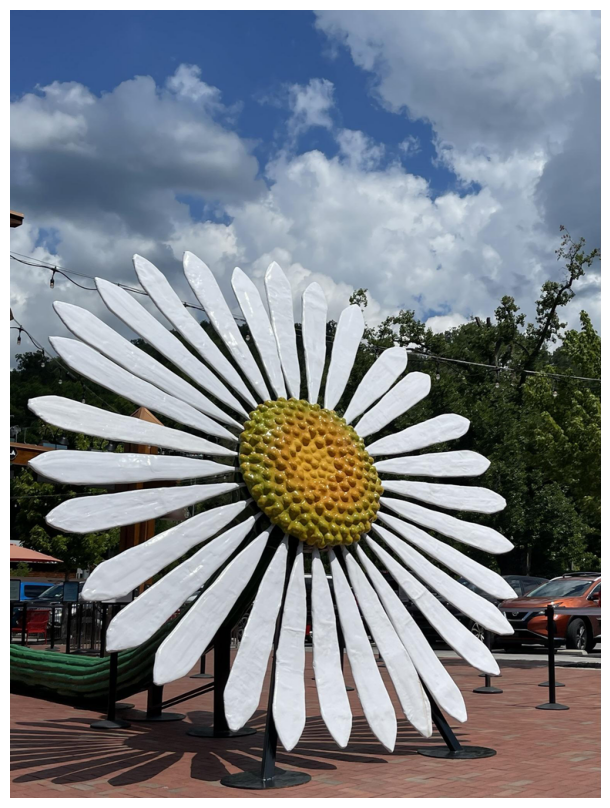

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# Path to the image
input_path = '/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg'

# Open the image
img = Image.open(input_path)

# Downscale factor
scale = 0.5
new_size = (int(img.width * scale), int(img.height * scale))

# Choose a high-quality downsampling filter
try:
    resample_filter = Image.Resampling.LANCZOS
except AttributeError:
    resample_filter = Image.LANCZOS

# Resize the image
img_resized = img.resize(new_size, resample=resample_filter)

# Display the resized image in the notebook cell
plt.figure(figsize=(new_size[0]/100, new_size[1]/100))
plt.axis('off')
plt.imshow(img_resized)
plt.show()


# Haing image sim

In [7]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt, in similarity của mỗi detail với text và với ảnh.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        path = img_path[i]
        
        # Encode image
        img = image_tensor[i].to(device)                      # [C,H,W]
        feat_image = model.encode_image(img.unsqueeze(0))     # [1,D]
        feat_image = feat_image / feat_image.norm(dim=-1, keepdim=True)
        feat_image = feat_image.squeeze(0)                    # [D]

        # Encode long text
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)            # [1,D]
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)                      # [D]
        
        # Split into details
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots_long': [],
                'dots_img': [],
                'weights': [],
                'num_details': 0,
                'path': path
            })
            continue
        
        # Encode all details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)     # [num_details, D]
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
        
        # Compute similarities
        detail_dots_long = feats_details @ feat_long          # [num_details]
        detail_dots_img  = feats_details @ feat_image         # [num_details]
        detail_weights   = torch.softmax(detail_dots_long, dim=0)
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots_long': detail_dots_long.tolist(),
            'dots_img': detail_dots_img.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results

if __name__ == '__main__':
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"

    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare DataLoader
    test_ds     = DocciDataset(split='test', max_items=None)
    test_loader = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Process first batch
    for batch in test_loader:
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        break

    # 4) Print results
    for r in results:
        print(f"Image path: {r['path']}")
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dl, di, w in zip(r['details'], r['dots_long'], r['dots_img'], r['weights']):
            print(f"  Detail: {det!r:50} → sim_long = {dl:.4f}, sim_img = {di:.4f}, weight = {w:.4f}")
        print("-" * 80)


Image path: /home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg
Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim_long = 0.6990, sim_img = 0.3963, weight = 0.2103
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim_long = 0.4679, sim_img = 0.3176, weight = 0.1669
  Detail: 'It is facin

In [8]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt, in similarity của mỗi detail với text và với ảnh.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        path = img_path[i]
        
        # Encode image
        img = image_tensor[i].to(device)                      # [C,H,W]
        feat_image = model.encode_image(img.unsqueeze(0))     # [1,D]
        feat_image = feat_image / feat_image.norm(dim=-1, keepdim=True)
        feat_image = feat_image.squeeze(0)                    # [D]

        # Encode long text
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)            # [1,D]
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)                      # [D]
        
        # Split into details
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots_long': [],
                'dots_img': [],
                'weights': [],
                'num_details': 0,
                'path': path
            })
            continue
        
        # Encode all details
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)     # [num_details, D]
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
        
        # Compute similarities
        detail_dots_long = feats_details @ feat_long          # [num_details]
        detail_dots_img  = feats_details @ feat_image         # [num_details]
        detail_weights   = torch.softmax(detail_dots_long, dim=0)
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots_long': detail_dots_long.tolist(),
            'dots_img': detail_dots_img.tolist(),
            'weights': detail_weights.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results

if __name__ == '__main__':
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"

    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare DataLoader
    test_ds     = DocciDataset(split='test', max_items=None)
    test_loader = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Process first batch
    for batch in test_loader:
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        break

    # 4) Print results
    for r in results:
        print(f"Image path: {r['path']}")
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dl, di, w in zip(r['details'], r['dots_long'], r['dots_img'], r['weights']):
            print(f"  Detail: {det!r:50} → sim_long = {dl:.4f}, sim_img = {di:.4f}, weight = {w:.4f}")
        print("-" * 80)


Image path: /home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg
Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim_long = 0.6904, sim_img = 0.3137, weight = 0.2010
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim_long = 0.5400, sim_img = 0.2213, weight = 0.1729
  Detail: 'It is facin

In [9]:
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt, tính sim và weight
    của mỗi detail với cả text và image.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        path = img_path[i]
        
        # --- encode image ---
        img = image_tensor[i].to(device)                      
        feat_image = model.encode_image(img.unsqueeze(0))     
        feat_image = feat_image / feat_image.norm(dim=-1, keepdim=True)
        feat_image = feat_image.squeeze(0)                    

        # --- encode long text ---
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)            
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)                      
        
        # --- split into details ---
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots_long': [],
                'dots_img': [],
                'weights_long': [],
                'weights_img': [],
                'num_details': 0,
                'path': path
            })
            continue
        
        # --- encode details ---
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)     
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
        
        # --- compute dot-products ---
        detail_dots_long = feats_details @ feat_long          
        detail_dots_img  = feats_details @ feat_image         

        # --- compute weights by softmax ---
        weights_long = torch.softmax(detail_dots_long, dim=0)
        weights_img  = torch.softmax(detail_dots_img,  dim=0)
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots_long': detail_dots_long.tolist(),
            'dots_img':  detail_dots_img.tolist(),
            'weights_long': weights_long.tolist(),
            'weights_img':  weights_img.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results

if __name__ == '__main__':
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"

    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare DataLoader
    test_ds     = DocciDataset(split='test', max_items=None)
    test_loader = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Process first batch
    for batch in test_loader:
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        break

    # 4) Print results
    for r in results:
        print(f"Image path: {r['path']}")
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dl, di, wl, wi in zip(
                r['details'], r['dots_long'], r['dots_img'],
                r['weights_long'], r['weights_img']):
            print(
                f"  Detail: {det!r:50} → "
                f"sim_long = {dl:.4f}, weight_long = {wl:.4f} | "
                f"sim_img = {di:.4f}, weight_img = {wi:.4f}"
            )
        print("-" * 80)


Image path: /home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg
Long text: An outdoor close-up of a tall metal daisy sculpture. The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. It is facing the front, right at an angle. The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. In the background, a tree line is visible. The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime.
Number of details: 7
  Detail: 'An outdoor close-up of a tall metal daisy sculpture' → sim_long = 0.6904, weight_long = 0.2010 | sim_img = 0.3137, weight_img = 0.1529
  Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow' → sim_long = 0.5400, weight_long = 0.1729 | sim_im

In [11]:
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace
import sys
sys.path.append("..")
from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 5) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 6) Compute + print sim
    sims = feats @ feat_img  # [N]
    for det, sim in zip(details, sims.tolist()):
        print(f"Detail: {det!r}\n  → sim_img = {sim:.4f}\n")

# Ví dụ dùng:
if __name__ == '__main__':
    long_text = (
        "An outdoor close-up of a tall metal daisy sculpture. "
        "The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. "
        "It is facing the front, right at an angle. "
        "The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. "
        "In the background, a tree line is visible. "
        "The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. "
        "The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


Detail: 'An outdoor close-up of a tall metal daisy sculpture'
  → sim_img = 0.3137

Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow'
  → sim_img = 0.2213

Detail: 'It is facing the front, right at an angle'
  → sim_img = 0.2156

Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it'
  → sim_img = 0.1715

Detail: 'In the background, a tree line is visible'
  → sim_img = 0.2128

Detail: 'The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds'
  → sim_img = 0.3069

Detail: 'The clouds are bright white right above the flower, with grayer clouds to the right and left'
  → sim_img = 0.2720



In [16]:
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace
import sys
sys.path.append("..")
from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Encode long text
    tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
    with torch.no_grad():
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)  # [D]

    # 5) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 6) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 7) Compute similarities & weights
    sims_text  = feats @ feat_long    # [N]
    sims_image = feats @ feat_img     # [N]
    weights_text  = torch.softmax(sims_text, dim=0)
    weights_image = torch.softmax(sims_image, dim=0)

    # 8) Print results
    for det, st, wt, si, wi in zip(details, sims_text.tolist(), weights_text.tolist(),
                                   sims_image.tolist(), weights_image.tolist()):
        print(f"Detail: {det!r}")
        print(f"  → sim_text  = {st:.4f}, weight_text  = {wt:.4f}")
        print(f"  → sim_image = {si:.4f}, weight_image = {wi:.4f}\n")

# Example usage:
if __name__ == '__main__':
    long_text = (
        "An outdoor close-up of a tall metal daisy sculpture. "
        "The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. "
        "It is facing the front, right at an angle. "
        "The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. "
        "In the background, a tree line is visible. "
        "The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. "
        "The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


Detail: 'An outdoor close-up of a tall metal daisy sculpture'
  → sim_text  = 0.6990, weight_text  = 0.2103
  → sim_image = 0.3963, weight_image = 0.1602

Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow'
  → sim_text  = 0.4679, weight_text  = 0.1669
  → sim_image = 0.3176, weight_image = 0.1481

Detail: 'It is facing the front, right at an angle'
  → sim_text  = -0.0716, weight_text  = 0.0973
  → sim_image = 0.2205, weight_image = 0.1344

Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it'
  → sim_text  = 0.1803, weight_text  = 0.1252
  → sim_image = 0.2112, weight_image = 0.1332

Detail: 'In the background, a tree line is visible'
  → sim_text  = -0.0792, weight_text  = 0.0966
  → sim_image = 0.1953, weight_image = 0.1311

Detail: 'The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds'
  → sim_text  = 0.4694, weight_text

In [15]:
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace
import sys
sys.path.append("..")
from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Encode long text
    tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
    with torch.no_grad():
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)  # [D]

    # 5) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 6) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 7) Compute similarities & weights
    sims_text  = feats @ feat_long    # [N]
    sims_image = feats @ feat_img     # [N]
    weights_text  = torch.softmax(sims_text, dim=0)
    weights_image = torch.softmax(sims_image, dim=0)

    # 8) Print results
    for det, st, wt, si, wi in zip(details, sims_text.tolist(), weights_text.tolist(),
                                   sims_image.tolist(), weights_image.tolist()):
        print(f"Detail: {det!r}")
        print(f"  → sim_text  = {st:.4f}, weight_text  = {wt:.4f}")
        print(f"  → sim_image = {si:.4f}, weight_image = {wi:.4f}\n")

# Example usage:
if __name__ == '__main__':
    long_text = (
        "An outdoor close-up of a tall metal daisy sculpture. "
        "The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. "
        "The daisy is facing the front, right at an angle. "
        "The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. "
        "In the background, a tree line is visible. "
        "The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. "
        "The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


Detail: 'An outdoor close-up of a tall metal daisy sculpture'
  → sim_text  = 0.7046, weight_text  = 0.2030
  → sim_image = 0.3963, weight_image = 0.1581

Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow'
  → sim_text  = 0.4825, weight_text  = 0.1626
  → sim_image = 0.3176, weight_image = 0.1461

Detail: 'The daisy is facing the front, right at an angle'
  → sim_text  = 0.2627, weight_text  = 0.1305
  → sim_image = 0.3178, weight_image = 0.1461

Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it'
  → sim_text  = 0.1762, weight_text  = 0.1197
  → sim_image = 0.2112, weight_image = 0.1314

Detail: 'In the background, a tree line is visible'
  → sim_text  = -0.0825, weight_text  = 0.0924
  → sim_image = 0.1953, weight_image = 0.1293

Detail: 'The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds'
  → sim_text  = 0.4691, weigh

In [14]:
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace
import sys
sys.path.append("..")
from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Encode long text
    tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
    with torch.no_grad():
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)  # [D]

    # 5) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 6) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 7) Compute similarities & weights
    sims_text  = feats @ feat_long    # [N]
    sims_image = feats @ feat_img     # [N]
    weights_text  = torch.softmax(sims_text, dim=0)
    weights_image = torch.softmax(sims_image, dim=0)

    # 8) Print results
    for det, st, wt, si, wi in zip(details, sims_text.tolist(), weights_text.tolist(),
                                   sims_image.tolist(), weights_image.tolist()):
        print(f"Detail: {det!r}")
        print(f"  → sim_text  = {st:.4f}, weight_text  = {wt:.4f}")
        print(f"  → sim_image = {si:.4f}, weight_image = {wi:.4f}\n")

# Example usage:
if __name__ == '__main__':
    long_text = (
        "An outdoor close-up of a tall metal daisy sculpture. "
        "The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow. "
        "It is facing the front, right at an angle. "
        "The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it. "
        "In the background, a tree line is visible. "
        "The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds. "
        "The clouds are bright white right above the flower, with grayer clouds to the right and left. Daytime."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00000.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


Detail: 'An outdoor close-up of a tall metal daisy sculpture'
  → sim_text  = 0.6904, weight_text  = 0.2010
  → sim_image = 0.3137, weight_image = 0.1529

Detail: 'The daisy has shiny, white fanned-out petals, and the embossed carpels in the center are painted yellow'
  → sim_text  = 0.5400, weight_text  = 0.1729
  → sim_image = 0.2213, weight_image = 0.1394

Detail: 'It is facing the front, right at an angle'
  → sim_text  = -0.0721, weight_text  = 0.0938
  → sim_image = 0.2156, weight_image = 0.1386

Detail: 'The ground below is a red brick, with a shadow of the sculpture visible on the surface right behind it'
  → sim_text  = 0.3328, weight_text  = 0.1405
  → sim_image = 0.1715, weight_image = 0.1326

Detail: 'In the background, a tree line is visible'
  → sim_text  = -0.0667, weight_text  = 0.0943
  → sim_image = 0.2128, weight_image = 0.1382

Detail: 'The daisy stretches right above the treetops, with a light blue sky above and puffy low clouds'
  → sim_text  = 0.4739, weight_text

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import sys
sys.path.append("..")
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace

from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Encode long text
    tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
    with torch.no_grad():
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)  # [D]

    # 5) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 6) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 7) Compute similarities & weights
    sims_text  = feats @ feat_long    # [N]
    sims_image = feats @ feat_img     # [N]
    weights_text  = torch.softmax(sims_text, dim=0)
    weights_image = torch.softmax(sims_image, dim=0)

    # 8) Print results
    for det, st, wt, si, wi in zip(details, sims_text.tolist(), weights_text.tolist(),
                                   sims_image.tolist(), weights_image.tolist()):
        print(f"Detail: {det!r}")
        print(f"  → sim_text  = {st:.4f}, weight_text  = {wt:.4f}")
        print(f"  → sim_image = {si:.4f}, weight_image = {wi:.4f}\n")
"Day time."
# Example usage:
if __name__ == '__main__':
    long_text = (
        "An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right. "
        "The sign has a black-line outline and is attached to a large, dark vertical pole that stretches from the top of the shot to the bottom. "
        "The sign has shadows and light reflections. "
        "The background is the blue sky, with a portion of the top of a tree to the right. "
        "The sun illuminates the top of the tree. "
        "A light pole extends to the left in the bottom corner of the shot. "
        "The light pole has two birds sitting apart on it. "
        "Day time."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_test_00003.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-22--11_14_58_-docci-spm-no-divide-9.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


/home/ubuntu/miniconda3/envs/kdpl/lib/python3.8/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Detail: 'An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right'
  → sim_text  = 0.8840, weight_text  = 0.2521
  → sim_image = 0.1946, weight_image = 0.1392

Detail: 'The sign has a black-line outline and is attached to a large, dark vertical pole that stretches from the top of the shot to the bottom'
  → sim_text  = 0.2235, weight_text  = 0.1302
  → sim_image = 0.2104, weight_image = 0.1414

Detail: 'The sign has shadows and light reflections'
  → sim_text  = 0.2319, weight_text  = 0.1313
  → sim_image = 0.2456, weight_image = 0.1465

Detail: 'The background is the blue sky, with a portion of the top of a tree to the right'
  → sim_text  = 0.1574, weight_text  = 0.1219
  → sim_image = 0.1910, weight_image = 0.1387

Detail: 'The sun illuminates the top of the tree'
  → sim_text  = 0.1999, weight_text  = 0.1272
  → sim_image = 0.2586, weight_image = 0.1484

Detail: 'A light pole extends to the left in the bott

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import sys
sys.path.append("..")
import torch
import clip
from PIL import Image
from model import longclip
from types import SimpleNamespace

from train import CLIP_Clean_Train

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

def compute_detail_similarities(long_text: str, image_path: str, ckpt_path: str, device: str = 'cuda'):
    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Load + preprocess image
    img = Image.open(image_path).convert('RGB')
    _, preprocess = clip.load("ViT-B/16", device=device)
    image_tensor = preprocess(img).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Encode image
    with torch.no_grad():
        feat_img = model.encode_image(image_tensor)
        feat_img = feat_img / feat_img.norm(dim=-1, keepdim=True)
        feat_img = feat_img.squeeze(0)  # [D]

    # 4) Encode long text
    tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
    with torch.no_grad():
        feat_long = model.encode_text(tokens_long)
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)  # [D]

    # 5) Split into detail sentences
    details = trainer.split_into_detail_captions(long_text)
    if not details:
        print("No detail sentences found.")
        return

    # 6) Tokenize + encode details
    tokens = longclip.tokenize(details, truncate=True).to(device)
    with torch.no_grad():
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    # 7) Compute similarities & weights
    sims_text  = feats @ feat_long    # [N]
    sims_image = feats @ feat_img     # [N]
    weights_text  = torch.softmax(sims_text, dim=0)
    weights_image = torch.softmax(sims_image, dim=0)

    # 8) Print results
    for det, st, wt, si, wi in zip(details, sims_text.tolist(), weights_text.tolist(),
                                   sims_image.tolist(), weights_image.tolist()):
        print(f"Detail: {det!r}")
        print(f"  → sim_text  = {st:.4f}, weight_text  = {wt:.4f}")
        print(f"  → sim_image = {si:.4f}, weight_image = {wi:.4f}\n")
""
# Example usage:
if __name__ == '__main__':
    long_text = (
        "An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right. "
        "The sign has a black-line outline and is attached to a large, dark vertical pole that stretches from the top of the shot to the bottom. "
        "The sign has shadows and light reflections. "
        "The background is the blue sky, with a portion of the top of a tree to the right. "
        "The sun illuminates the top of the tree. "
        "A light pole extends to the left in the bottom corner of the shot. "
        "The light pole has two birds sitting apart on it. "
        "Day time."
    )
    image_path = "/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/qual_dev_00002.jpg"
    ckpt_path  = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-20--18_41_54_-docci-no.pt"
    compute_detail_similarities(long_text, image_path, ckpt_path)


Detail: 'An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right'
  → sim_text  = 0.8749, weight_text  = 0.2439
  → sim_image = 0.0346, weight_image = 0.1308

Detail: 'The sign has a black-line outline and is attached to a large, dark vertical pole that stretches from the top of the shot to the bottom'
  → sim_text  = 0.2985, weight_text  = 0.1370
  → sim_image = 0.1750, weight_image = 0.1505

Detail: 'The sign has shadows and light reflections'
  → sim_text  = 0.3012, weight_text  = 0.1374
  → sim_image = 0.1842, weight_image = 0.1518

Detail: 'The background is the blue sky, with a portion of the top of a tree to the right'
  → sim_text  = 0.2176, weight_text  = 0.1264
  → sim_image = 0.1108, weight_image = 0.1411

Detail: 'The sun illuminates the top of the tree'
  → sim_text  = 0.1539, weight_text  = 0.1186
  → sim_image = 0.1070, weight_image = 0.1406

Detail: 'A light pole extends to the left in the bott

In [6]:
{
        "id": "qual_test_00003",
        "image": "docci_images/images/qual_test_00003.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "A high-angle shot of an outdoor path light in a corner of a dried grass yard."
            },
            {
                "from": "llava",
                "value": "A high-angle shot of an outdoor path light in a corner of a dried grass yard. The scene is at night, with the patch light illuminating the center of the frame. It has a black rounded cap, and the light creates a round diamond-shaped kaleidoscopic pattern that ripples out with pointed refracted lights towards the outer layer. The upper left and bottom left show driveway concrete appearing mostly dark. On the bottom right is a stack of decorative rocks, mostly out of view. To the right, next to the light, is a brown, round metal sewage cap. The upper right shows a bush appearing black, with a slight view of a similar path light, mostly out of the frame."
            }
        ]
    }

{
        "id": "qual_test_00004",
        "image": "docci_images/images/qual_test_00004.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "An indoor close-up shot of a grey Hot Wheels roger dodger steam punk car with its silver engine components protruding from the hood facing the right in front of a toy polar bear and a small brown horse toy."
            },
            {
                "from": "llava",
                "value": "An indoor close-up shot of a grey Hot Wheels roger dodger steam punk car with its silver engine components protruding from the hood facing the right in front of a toy polar bear and a small brown horse toy. The polar bear and horse are also facing the right. Polar bears positioned on all fours with its right side legs forward as if it's a walking. The black tip nose of the polar bear is slightly worn. The small brown horse stands with all four hooves flat. Multiple Shadows of the objects are cast towards the left and right, indicating multiple light sources. A bright white light is shining from the far left side. The surface underneath the toys is plain smooth white and the background is a wood panel wall."
            }
        ]
    }

{
        "id": "qual_test_00008",
        "image": "docci_images/images/qual_test_00008.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "An outdoor medium shot of pink, orange, yellow, blue, and purple balloon garland shaped into the numbers \"3\" and \"0\" standing about 10 ft high underneath the tall bushy branches of large trees in a residential front yard."
            },
            {
                "from": "llava",
                "value": "An outdoor medium shot of pink, orange, yellow, blue, and purple balloon garland shaped into the numbers \"3\" and \"0\" standing about 10 ft high underneath the tall bushy branches of large trees in a residential front yard. A concrete walkway to the tan house's front door is to the left of the balloon garland. The house has four windows on the front where yellow lights from the inside are visible. A concrete driveway to the right has two concrete steps next to a blue trash bin and a green recycling bin. Light gray skies can be seen through the branches of the above trees."
            }
        ]
    },

{
        "id": "qual_test_00010",
        "image": "docci_images/images/qual_test_00010.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "A medium-close-up view of four large square windows that are separated by thin square poles that run vertically and horizontally."
            },
            {
                "from": "llava",
                "value": "A medium-close-up view of four large square windows that are separated by thin square poles that run vertically and horizontally. The two bottom windows can hardly be seen; for the one on the right, only the top left corner of it is visible, and the top portion of the one on the left can be seen. Reflecting off of the window on the left is the headlight of a car, and on the headlight there are two circles that are giving off-white light. There is also one on the right that is partially covered by a pole. On these windows, there is a white film that partially covers them. The windows along the top are clear, and you can see inside a building. Through the window on the right, seven whitewashing machines can be seen, and along these machines there are gray circles that have a black glass, while on the rear wall it is brown, and above the brown part there are red lines that move horizontally, and above the red line it is white. Along the ceiling, a singular rectangular white light can be seen along the back, and surrounding the light are rectangular panels."
            }
        ]
    }

{
        "id": "qual_test_00014",
        "image": "docci_images/images/qual_test_00014.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "A white cat with patches of black fur on the top of its head is standing with its front paws on a brown wooden floor and its back paws on a gray and blue square patterned tile floor."
            },
            {
                "from": "llava",
                "value": "A white cat with patches of black fur on the top of its head is standing with its front paws on a brown wooden floor and its back paws on a gray and blue square patterned tile floor. The cat's body faces to the right of the image, while its head is turned forward and slightly upward to the left. On the top of the cat's nose is a white sticker with \"6407\" written in black. Behind the cat, a white open door with a white frame is on the right side of the image. Light is shining from the top right corner of the image. Indoor, daytime."
            }
        ]
    },


"shade"

{
        "id": "qual_test_00033",
        "image": "docci_images/images/qual_test_00033.jpg",
        "split": "qual_test",
        "conversations": [
            {
                "from": "human",
                "value": "A small cup of milky coffee with a paint brush is seen close below from an angle."
            },
            {
                "from": "llava",
                "value": "A small cup of milky coffee with a paint brush is seen close below from an angle. The paint brush lies in front of the cup of coffee, with its short white bristles on the left. It has a warm brown leather band around the top of the bristles that meets the pale beige wood of the handle. A clear label reads \"COFFEE GROUND BRUSH\" in black letters. The coffee cup is lined up with the paint brush handle, which has its own handle on the left. The cup is shiny light blue with a special glazing technique, leaving an area of the white undercoat unglazed in blue. The coffee itself is a caramel color, with bubbles in the center. The larger bubbles show a tiny amount of dark brown under them. The counter top the objects lay on is a gray variation with small white smears. A very shiny surface behind the objects shows a brown variation shade and the nearly perfect reflections of the objects. A small spot of light reflects off the gray surface on the bottom edge of the image."
            }
        ]
    }


{
        "id": "test_00059",
        "image": "docci_images/images/test_00059.jpg",
        "split": "test",
        "conversations": [
            {
                "from": "human",
                "value": "A close up view of a child's play area that consist of building designs."
            },
            {
                "from": "llava",
                "value": "A close up view of a child's play area that consist of building designs. The building is white with a baby blue trim and roof. Another blue building is behind the white one. A dark opening is behind the white building painting as well. A window is to the right of the white building design. A reflection is on the window showing a large real life building. Another window is to the left of the white building design and in front of the blue building. White stair rails are to the right in the background. The floor has dark gray concrete covering it. A black ceiling is over the play area. Five black illuminated lights are seen in the background on the ceiling."
            }
        ]
    }

{
        "id": "test_00315",
        "image": "docci_images/images/test_00315.jpg",
        "split": "test",
        "conversations": [
            {
                "from": "human",
                "value": "An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right."
            },
            {
                "from": "llava",
                "value": "An outdoor medium shot, looking up at a yellow, weathered, diamond-shaped caution sign with a black horse and buggy facing the right. The sign has a black-line outline and is attached to a large, dark vertical pole that stretches from the top of the shot to the bottom. The sign has shadows and light reflections. The background is the blue sky, with a portion of the top of a tree to the right. The sun illuminates the top of the tree. A light pole extends to the left in the bottom corner of the shot. The light pole has two birds sitting apart on it. Day time."
            }
        ]
    },

{
        "id": "test_00327",
        "image": "docci_images/images/test_00327.jpg",
        "split": "test",
        "conversations": [
            {
                "from": "human",
                "value": "A slightly high angled close up view of a plant with illuminated bright green smooth edged leaves."
            },
            {
                "from": "llava",
                "value": "A slightly high angled close up view of a plant with illuminated bright green smooth edged leaves. Behind the plant is a partially visible wooden wall that covers up three fourths of the background from the top. Four horizontally aligned planks are visible across the background on the wall from the top to the lower middle of the view behind the plant. The lowest plank is cracked or splinters horizontally all the way across on its lower half. On the ground below the plant is dirt and soil with rocks and twigs visible on the ground in the bottom left corner. In the bottom right on the ground are very small green colored plants. Below the illuminated bright green leaved plant in the middle of the view is a darker green colored weed on the ground that is spread wide and not vertically. Light shines onto the central plant from the left side of the view, a shadow is cast onto the wooden planks behind the plant toward the right and lower right. The central plant in the image is visible from the lower middle of the view up toward the top of the view."
            }
        ]
    },


{
        "id": "test_00377",
        "image": "docci_images/images/test_00377.jpg",
        "split": "test",
        "conversations": [
            {
                "from": "human",
                "value": "An outdoor view of a neon light art sculpture installation."
            },
            {
                "from": "llava",
                "value": "An outdoor view of a neon light art sculpture installation. The art is of a tall, skinny elephant with tusks. The legs are elongated a great deal in proportion to the body. The neon lights are aqua blue. The tusks are white neon outlines. The neon lights are thin illuminated tubes over black metal. The elephant is facing to the left. The legs have three sections of neon that make all four legs look like a skeleton. The top thigh portion has the shape of a chicken drumstick. The background behind the legs of the elephant is a landscaped flower bed with green ferns and grasses. Above the landscaped bed are tall mature tree trunks and a leaf canopy. The background trees fill the top three quarters of the frame. At the very bottom edge to the right is a concrete platform with an iron plate on it, that the art is attached to."
            }
        ]
    },


{
        "id": "test_00401",
        "image": "docci_images/images/test_00401.jpg",
        "split": "test",
        "conversations": [
            {
                "from": "human",
                "value": "An outdoor view of a white wasp nest, the nest has a papery like appearance and is shaped like an upside down umbrella with numerous holes on its underside."
            },
            {
                "from": "llava",
                "value": "An outdoor view of a white wasp nest, the nest has a papery like appearance and is shaped like an upside down umbrella with numerous holes on its underside. The nest has a white grayish color. multiple wasps grouped up and visible on the bottom of the nest. The nest is attached to a partially visible thin brown tree with one of the cylinder shaped brown branches pointed outward to the top left of the view. On the right side of the view next to the thin tree, are numerous green stems and leaves that block the background on the right from view. On the upper left and middle of the view the clouded blue sky is visible. Light partially shines onto the image, the nest is partially illuminated on the middle and upper portions from sunlight, as well as the closest stems and leaves in the view bright from sunlight. Shadows are cast under the nest and in between the stems and leaves. The background of the image is quite blurry and out of focus, while the foreground, nest, and nearby stems on the right side of the view are very focused and clear."
            }
        ]
    },





({'id': 'test_00401',
  'image': 'docci_images/images/test_00401.jpg',
  'split': 'test',
  'conversations': [{'from': 'human',
    'value': 'An outdoor view of a white wasp nest, the nest has a papery like appearance and is shaped like an upside down umbrella with numerous holes on its underside.'},
   {'from': 'llava',
    'value': 'An outdoor view of a white wasp nest, the nest has a papery like appearance and is shaped like an upside down umbrella with numerous holes on its underside. The nest has a white grayish color. multiple wasps grouped up and visible on the bottom of the nest. The nest is attached to a partially visible thin brown tree with one of the cylinder shaped brown branches pointed outward to the top left of the view. On the right side of the view next to the thin tree, are numerous green stems and leaves that block the background on the right from view. On the upper left and middle of the view the clouded blue sky is visible. Light partially shines onto the image, t

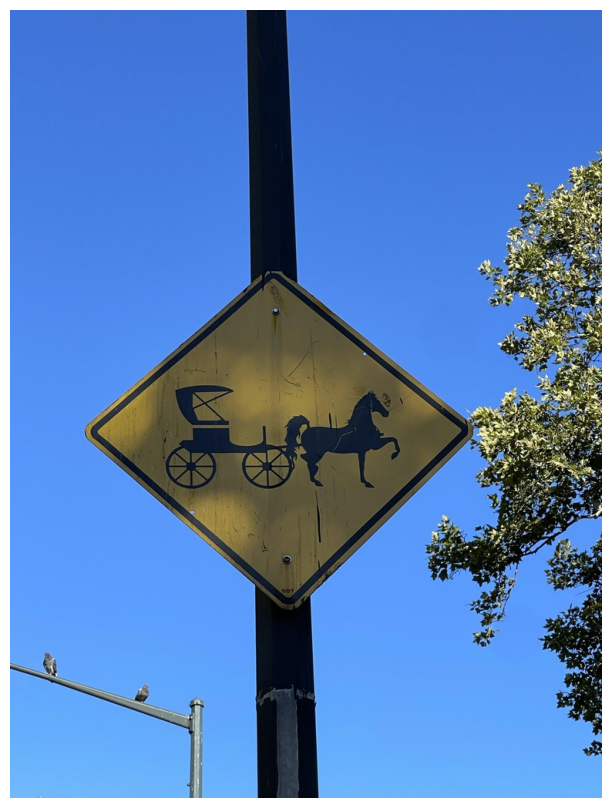

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# Path to the image
input_path = '/home/ubuntu/shared/hieu.tq/dreamlip_long_captions/docci/docci_images/images/test_00315.jpg'

# Open the image
img = Image.open(input_path)

# Downscale factor
scale = 0.5
new_size = (int(img.width * scale), int(img.height * scale))

# Choose a high-quality downsampling filter
try:
    resample_filter = Image.Resampling.LANCZOS
except AttributeError:
    resample_filter = Image.LANCZOS

# Resize the image
img_resized = img.resize(new_size, resample=resample_filter)

# Display the resized image in the notebook cell
plt.figure(figsize=(new_size[0]/100, new_size[1]/100))
plt.axis('off')
plt.imshow(img_resized)
plt.show()


# DCI

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt, tính sim và weight
    của mỗi detail với cả text và image.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    results = []
    
    for i in range(B):
        long_text = long_texts[i]
        path = img_path[i]
        
        # --- encode image ---
        img = image_tensor[i].to(device)                      
        feat_image = model.encode_image(img.unsqueeze(0))     
        feat_image = feat_image / feat_image.norm(dim=-1, keepdim=True)
        feat_image = feat_image.squeeze(0)                    

        # --- encode long text ---
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)            
        feat_long = feat_long / feat_long.norm(dim=-1, keepdim=True)
        feat_long = feat_long.squeeze(0)                      
        
        # --- split into details ---
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [],
                'dots_long': [],
                'dots_img': [],
                'weights_long': [],
                'weights_img': [],
                'num_details': 0,
                'path': path
            })
            continue
        
        # --- encode details ---
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)     
        feats_details = feats_details / feats_details.norm(dim=-1, keepdim=True)
        
        # --- compute dot-products ---
        detail_dots_long = feats_details @ feat_long          
        detail_dots_img  = feats_details @ feat_image         

        # --- compute weights by softmax ---
        weights_long = torch.softmax(detail_dots_long, dim=0)
        weights_img  = torch.softmax(detail_dots_img,  dim=0)
        
        results.append({
            'long_text': long_text,
            'details': details,
            'dots_long': detail_dots_long.tolist(),
            'dots_img':  detail_dots_img.tolist(),
            'weights_long': weights_long.tolist(),
            'weights_img':  weights_img.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results

if __name__ == '__main__':
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-23--11_35_11_-dci-no-5.pt"

    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare DataLoader
    test_ds  = JsonDCIDataset(
        json_path="/home/ubuntu/hieu.tq/Git/GOAL/datasets/DCI_test.json",
        max_items=None
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Process first batch
    for batch in test_loader:
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        break

    # 4) Print results
    for r in results:
        print(f"Image path: {r['path']}")
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dl, di, wl, wi in zip(
                r['details'], r['dots_long'], r['dots_img'],
                r['weights_long'], r['weights_img']):
            print(
                f"  Detail: {det!r:50} \n → "
                f"sim_long = {dl:.4f}, weight_long = {wl:.4f} | "
                f"sim_img = {di:.4f}, weight_img = {wi:.4f}"
            )
        print("-" * 80)


Image path: /home/ubuntu/shared/hieu.tq/DCI/data/densely_captioned_images/photos/sa_1543972.jpg
Long text: An indoor mall with three illuminated escalators. The mall has various planters with lush greenery on both sides of the escalator. The floor is polished with colored tiles. A man can be seen ascending the left elevator. Some shops on the second floor appear to be open and some closed. The ceiling has recessed lighting and there are several stone columns.
Number of details: 6
  Detail: 'An indoor mall with three illuminated escalators' 
 → sim_long = 0.8540, weight_long = 0.2246 | sim_img = 0.2888, weight_img = 0.1759
  Detail: 'The mall has various planters with lush greenery on both sides of the escalator' 
 → sim_long = 0.7603, weight_long = 0.2045 | sim_img = 0.2570, weight_img = 0.1704
  Detail: 'The floor is polished with colored tiles'         
 → sim_long = 0.3629, weight_long = 0.1374 | sim_img = 0.2196, weight_img = 0.1642
  Detail: 'A man can be seen ascending the left e

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch
import torch.nn.functional as F
import sys
sys.path.append("..")
from model import longclip

from types import SimpleNamespace
from train import CLIP_Clean_Train
from docci import DocciDataset
from dci import JsonDCIDataset
from torch.utils.data import DataLoader

def load_trainer_and_model(ckpt_path: str, device: str = 'cuda'):
    args = SimpleNamespace(
        base_model='ViT-B/16',
        download_root=None,
        log_scale=4.6052,
        batch_size=64,
        epochs=1,
        lr=1e-5,
        refine_lr_image=2e-6,
        refine_lr_text=2e-4,
        weight_decay=0.01,
        warmup_length=200,
        exp_name='inference',
        ckpt_path=ckpt_path
    )
    trainer = CLIP_Clean_Train(args)
    state   = torch.load(ckpt_path, map_location='cpu')
    trainer.model.load_state_dict(state, strict=False)
    model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
    return model.to(device).eval(), trainer

@torch.no_grad()
def encode_and_compare_dynamic(batch, trainer, model, device):
    """
    Xử lý từng sample riêng biệt, tính sim và weight
    của mỗi detail với cả text và image, dùng MLP learnable.
    """
    image_tensor, long_texts, caption_short, img_path, split = batch
    B = len(long_texts)
    results = []
    
    for i in range(B):
        # --- prep ---
        long_text = long_texts[i]
        path = img_path[i]
        img = image_tensor[i].to(device)
        
        # --- encode image global ---
        feat_image = model.encode_image(img.unsqueeze(0))    # [1, D]
        feat_image = F.normalize(feat_image, dim=-1).squeeze(0)  # [D]
        
        # --- encode long text ---
        tokens_long = longclip.tokenize([long_text], truncate=True).to(device)
        feat_long = model.encode_text(tokens_long)           # [1, D]
        feat_long = F.normalize(feat_long, dim=-1).squeeze(0)    # [D]
        
        # --- split & encode details ---
        details = trainer.split_into_detail_captions(long_text)
        num_details = len(details)
        if num_details == 0:
            results.append({
                'long_text': long_text,
                'details': [], 'dots_long': [], 'dots_img': [],
                'weights_long': [], 'weights_img': [],
                'num_details': 0, 'path': path
            })
            continue
        
        tokens_details = longclip.tokenize(details, truncate=True).to(device)
        feats_details = model.encode_text(tokens_details)    # [N, D]
        feats_details = F.normalize(feats_details, dim=-1)  # [N, D]
        
        # --- compute dot-products (chỉ để so sánh/log) ---
        detail_dots_long = feats_details @ feat_long        # [N]
        detail_dots_img  = feats_details @ feat_image      # [N]
        
        # --- compute weights via the MLP you trained ---
        # long-caption based weights
        long_exp = feat_long.unsqueeze(0).expand_as(feats_details)  # [N, D]
        inp_long = torch.cat([feats_details, long_exp], dim=1)      # [N, 2D]
        logits_long = model.weight_mlp(inp_long).squeeze(-1)        # [N]
        weights_long = torch.softmax(logits_long, dim=0)            # [N]
        
        # image-based weights
        img_exp = feat_image.unsqueeze(0).expand_as(feats_details)  # [N, D]
        inp_img = torch.cat([feats_details, img_exp], dim=1)        # [N, 2D]
        logits_img = model.weight_mlp(inp_img).squeeze(-1)          # [N]
        weights_img = torch.softmax(logits_img, dim=0)              # [N]
        
        # --- collect kết quả ---
        results.append({
            'long_text': long_text,
            'details': details,
            'dots_long': detail_dots_long.tolist(),
            'dots_img':  detail_dots_img.tolist(),
            'weights_long': weights_long.tolist(),
            'weights_img':  weights_img.tolist(),
            'num_details': num_details,
            'path': path
        })
    
    return results


if __name__ == '__main__':
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt_path = "/home/ubuntu/hieu.tq/Git/KDPL_test/KDPL/src/LongCLIPMul_docci/train/longclip/lr=1e-06_wd=0.01_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-06-24--07_09_05_-dci-both-mlp-5.pt"

    # 1) Load model & trainer
    model, trainer = load_trainer_and_model(ckpt_path, device)

    # 2) Prepare DataLoader
    test_ds  = JsonDCIDataset(
        json_path="/home/ubuntu/hieu.tq/Git/GOAL/datasets/DCI_test.json",
        max_items=None
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # 3) Process first batch
    for batch in test_loader:
        results = encode_and_compare_dynamic(batch, trainer, model, device)
        break

    # 4) Print results
    for r in results:
        print(f"Image path: {r['path']}")
        print(f"Long text: {r['long_text']}")
        print(f"Number of details: {r['num_details']}")
        for det, dl, di, wl, wi in zip(
                r['details'], r['dots_long'], r['dots_img'],
                r['weights_long'], r['weights_img']):
            print(
                f"  Detail: {det!r:50} \n → "
                f"sim_long = {dl:.4f}, weight_long = {wl:.4f} | "
                f"sim_img = {di:.4f}, weight_img = {wi:.4f}"
            )
        print("-" * 80)


Image path: /home/ubuntu/shared/hieu.tq/DCI/data/densely_captioned_images/photos/sa_1543972.jpg
Long text: An indoor mall with three illuminated escalators. The mall has various planters with lush greenery on both sides of the escalator. The floor is polished with colored tiles. A man can be seen ascending the left elevator. Some shops on the second floor appear to be open and some closed. The ceiling has recessed lighting and there are several stone columns.
Number of details: 6
  Detail: 'An indoor mall with three illuminated escalators' 
 → sim_long = 0.8348, weight_long = 0.1699 | sim_img = 0.2931, weight_img = 0.1698
  Detail: 'The mall has various planters with lush greenery on both sides of the escalator' 
 → sim_long = 0.7021, weight_long = 0.1688 | sim_img = 0.2676, weight_img = 0.1689
  Detail: 'The floor is polished with colored tiles'         
 → sim_long = 0.3177, weight_long = 0.1660 | sim_img = 0.2269, weight_img = 0.1661
  Detail: 'A man can be seen ascending the left e